<a href="https://colab.research.google.com/github/mallelamanojkumar90/AIML/blob/main/knn_using_sciktlearn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 1. Import necessary libraries

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Create a Sample Dataset
Let's create a simple dataset with two features (X) and two classes (y) for demonstration.

First 5 rows of the dataset:


,Feature_1,Feature_2,Target
0,3.745401,9.507143,1
1,7.319939,5.986585,0
2,1.560186,1.559945,0
3,0.580836,8.661761,0
4,6.011150,7.080726,1


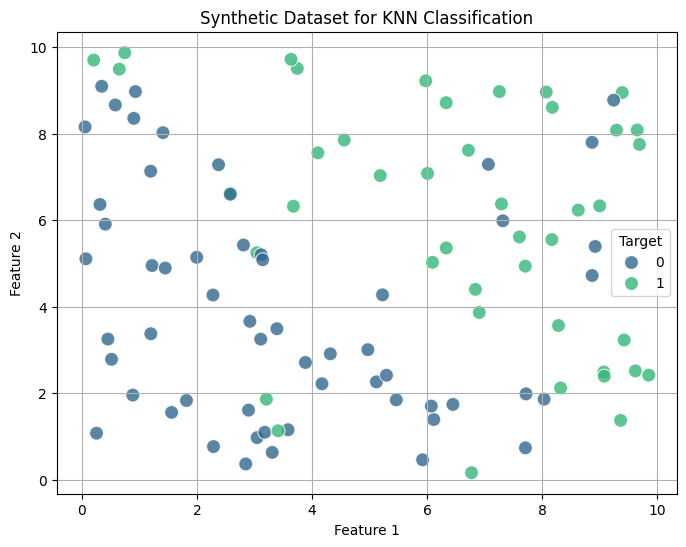

In [9]:
# Generate synthetic data
np.random.seed(42)
X = np.random.rand(100, 2) * 10  # 100 samples, 2 features, values from 0-10
y = (X[:, 0] + X[:, 1] > 10).astype(int) # Simple classification rule

# Add some noise to make it less perfectly separable
noise_mask = np.random.rand(100) < 0.1
y[noise_mask] = 1 - y[noise_mask]

df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])
df['Target'] = y

print("First 5 rows of the dataset:")
display(df.head())

# Visualize the data
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Feature_1', y='Feature_2', hue='Target', data=df, palette='viridis', s=100, alpha=0.8)
plt.title('Synthetic Dataset for KNN Classification')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.grid(True)
plt.show()

### 3. Split the Data into Training and Testing Sets
This step is crucial to evaluate the model's performance on unseen data. We'll use 70% of the data for training and 30% for testing.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Training data shape: (70, 2)
Testing data shape: (30, 2)


### 4. Initialize and Train the KNN Classifier
We'll initialize `KNeighborsClassifier` and choose `n_neighbors=5` (meaning K=5). Then, we'll train the model using our training data.

In [4]:
# Initialize the KNN classifier with K=5
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model using the training data
knn.fit(X_train, y_train)

print("KNN model trained successfully with K=5.")

KNN model trained successfully with K=5.


### 5. Make Predictions
Now that the model is trained, we can use it to predict the class labels for our test data.

In [5]:
# Make predictions on the test set
y_pred = knn.predict(X_test)

print("First 10 actual labels from test set:", y_test[:10])
print("First 10 predicted labels for test set:", y_pred[:10])

First 10 actual labels from test set: [0 1 1 0 1 0 0 1 0 1]
First 10 predicted labels for test set: [0 0 1 0 1 0 0 0 0 1]


### 6. Evaluate the Model's Performance
We'll use accuracy score and a classification report to evaluate how well our KNN model performed on the test data.

In [6]:
# Calculate the accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Display the classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.93

Classification Report:
              precision    recall  f1-score   support

           0       0.88      1.00      0.94        15
           1       1.00      0.87      0.93        15

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



### Visualizing the Decision Boundary (Optional but helpful)
This visualization shows how the KNN model divides the feature space into different classes.

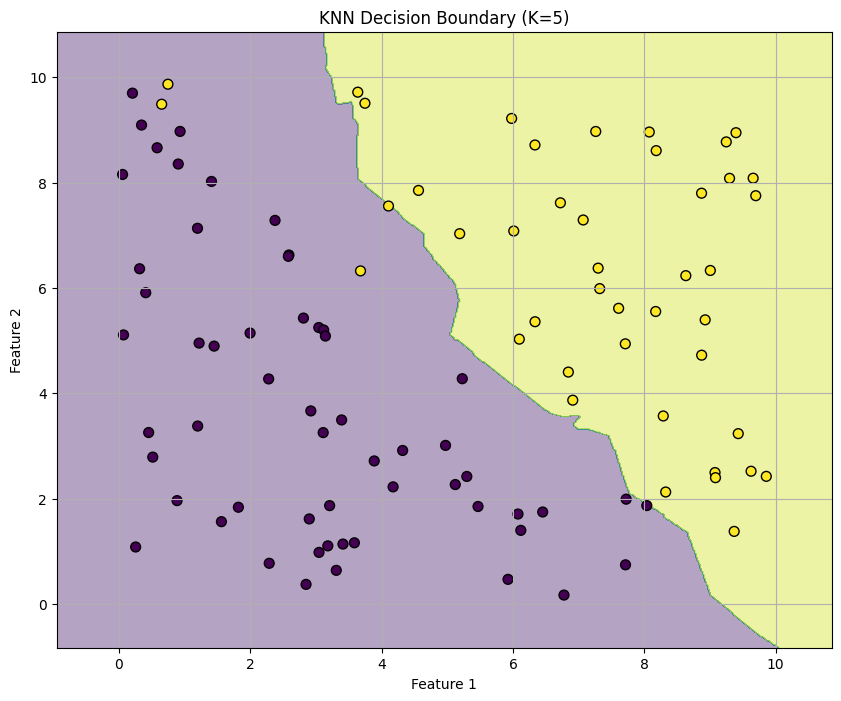

In [7]:
def plot_decision_boundary(X, y, model, title):
    h = .02  # step size in the mesh
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(10, 8))
    plt.contourf(xx, yy, Z, alpha=0.4, cmap='viridis')
    plt.scatter(X[:, 0], X[:, 1], c=y, s=50, edgecolor='k', cmap='viridis')
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.grid(True)
    plt.show()

plot_decision_boundary(X, y, knn, 'KNN Decision Boundary (K=5)')

This code demonstrates the full workflow of using KNN for classification in Python with Scikit-Learn: from data generation and splitting to model training, prediction, and evaluation.